# Employee Attrition Analytics

## Module 4: Exploratory Data Analysis

### Objective
Explore the cleaned employee dataset, identify patterns and relationships, and generate business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Clean Dataset

In [2]:
df = pd.read_csv("../data/processed/employee_hr_analytics_clean.csv")
df.head()

,Employee_ID,Age,Gender,Department,Job_Role,Experience,Education,Salary,Performance_Score,Job_Satisfaction,...,Remote_Work,Training_Hours,Projects,Promotion_Last_5Yrs,Joining_Date,Attrition,City,Employment_Type,Manager_Rating,Sick_Leaves
0,1,40.0,Male,Sales,Sales Manager,3,Master,94113.0,5,6.0,...,No,70,5,No,2011-12-21,No,Rawalpindi,Contract,5,6
1,2,39.0,Female,Sales,Sales Manager,2,Master,54224.0,4,9.0,...,No,33,3,Yes,2015-09-20,No,Islamabad,Full-Time,4,4
2,3,49.0,Male,Finance,Financial Analyst,25,Master,166749.0,2,6.0,...,Yes,75,12,No,2014-12-10,No,Islamabad,Full-Time,8,2
3,4,54.0,Female,Marketing,Marketing Specialist,26,Bachelor,196590.0,5,4.0,...,Yes,64,12,No,2022-08-23,Yes,Rawalpindi,Contract,4,5
4,5,41.0,Female,IT,Data Analyst,18,PhD,231764.0,3,8.0,...,Yes,15,12,No,2021-09-29,No,Rawalpindi,Contract,10,8


## Inspect Dataset

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.to_list())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1000, 22)

Columns:
['Employee_ID', 'Age', 'Gender', 'Department', 'Job_Role', 'Experience', 'Education', 'Salary', 'Performance_Score', 'Job_Satisfaction', 'Overtime', 'Work_Hours', 'Remote_Work', 'Training_Hours', 'Projects', 'Promotion_Last_5Yrs', 'Joining_Date', 'Attrition', 'City', 'Employment_Type', 'Manager_Rating', 'Sick_Leaves']

Data Types:
Employee_ID              int64
Age                    float64
Gender                     str
Department                 str
Job_Role                   str
Experience               int64
Education                  str
Salary                 float64
Performance_Score        int64
Job_Satisfaction       float64
Overtime                   str
Work_Hours               int64
Remote_Work                str
Training_Hours           int64
Projects                 int64
Promotion_Last_5Yrs        str
Joining_Date               str
Attrition                  str
City                       str
Employment_Type            str
Manager_Rat

## Numerical Variables

In [4]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns.tolist())

['Employee_ID', 'Age', 'Experience', 'Salary', 'Performance_Score', 'Job_Satisfaction', 'Work_Hours', 'Training_Hours', 'Projects', 'Manager_Rating', 'Sick_Leaves']


## Categorical Variables

In [5]:
categorical_columns = df.select_dtypes(include="object").columns
print(categorical_columns.tolist())

['Gender', 'Department', 'Job_Role', 'Education', 'Overtime', 'Remote_Work', 'Promotion_Last_5Yrs', 'Joining_Date', 'Attrition', 'City', 'Employment_Type']


/var/folders/0q/p4lq41ks1b3_d8y18kdvg8x80000gn/T/ipykernel_13010/3571026026.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


## Gender Distribution

In [6]:
gender_counts = df["Gender"].value_counts()
gender_counts

Gender
Female    533
Male      467
Name: count, dtype: int64

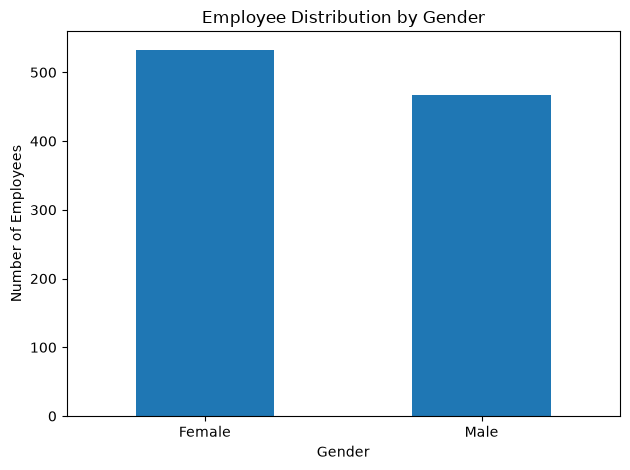

In [7]:
plt.Figure(figsize=(7, 5))
gender_counts.plot(kind="bar")

plt.title("Employee Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Employee Distribution by Department

In [8]:
department_counts = df["Department"].value_counts()
department_counts

Department
HR           229
Sales        199
Marketing    196
Finance      194
IT           182
Name: count, dtype: int64

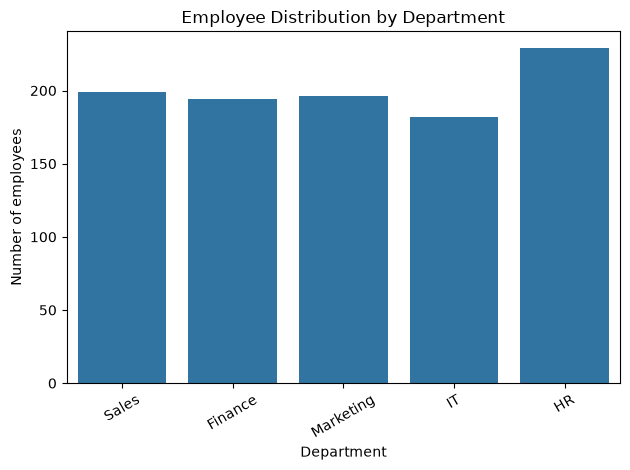

In [9]:
plt.Figure(figsize=(8, 5))

sns.countplot(data=df, x="Department")

plt.title("Employee Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of employees")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Employee Age Distribution

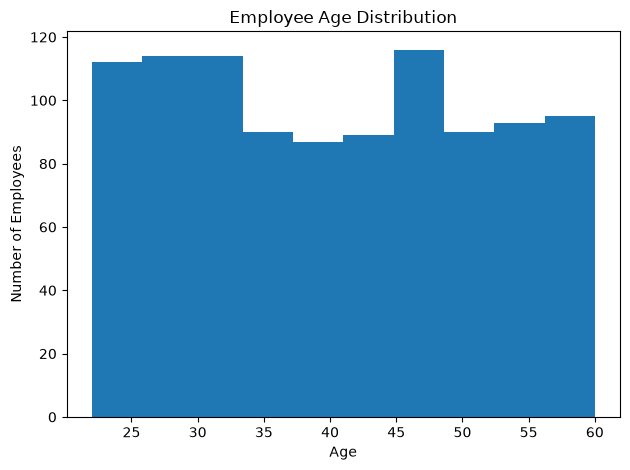

In [10]:
plt.Figure(figsize=(8, 5))
plt.hist(df["Age"], bins=10)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## Salary Distribution

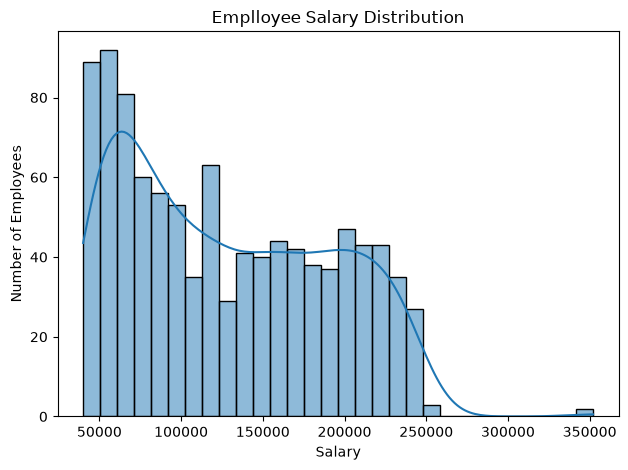

In [11]:
plt.Figure(figsize=(8, 5))
sns.histplot(data=df, x="Salary", bins=30, kde=True)

plt.title("Emplloyee Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## Salary Analysis by Department

In [12]:
salary_by_department = (
    df.groupby("Department")["Salary"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)
salary_by_department

,mean,median,min,max
Department,,,,
Finance,133855.963273,124553.50,40183.0,352095.375
Marketing,128487.834184,119197.50,40687.0,249211.000
IT,128005.054258,119427.75,40039.0,352095.375
HR,127708.982533,119494.00,40486.0,249404.000
Sales,121986.391960,102114.00,40104.0,240518.000


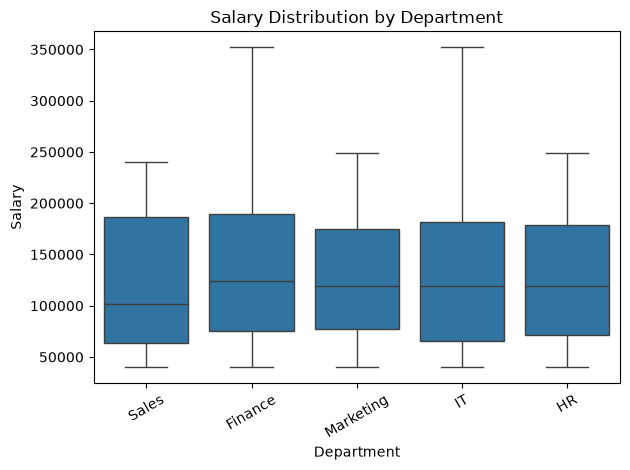

In [13]:
plt.Figure(figsize=(9, 5))
sns.boxplot(data=df, x="Department", y="Salary")

plt.title("Salary Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Salary")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Relationship Between Experience and Salary

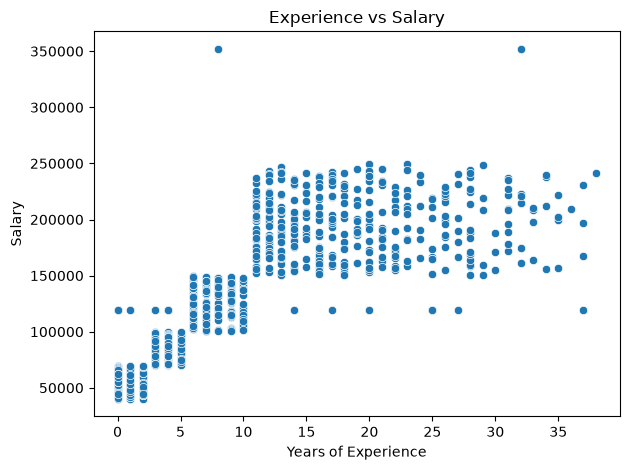

In [14]:
plt.Figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Experience", y="Salary")

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()

## Employee Performance Distribution

In [15]:
performance_counts = df["Performance_Score"].value_counts().sort_index()
performance_counts

Performance_Score
1    195
2    211
3    194
4    199
5    201
Name: count, dtype: int64

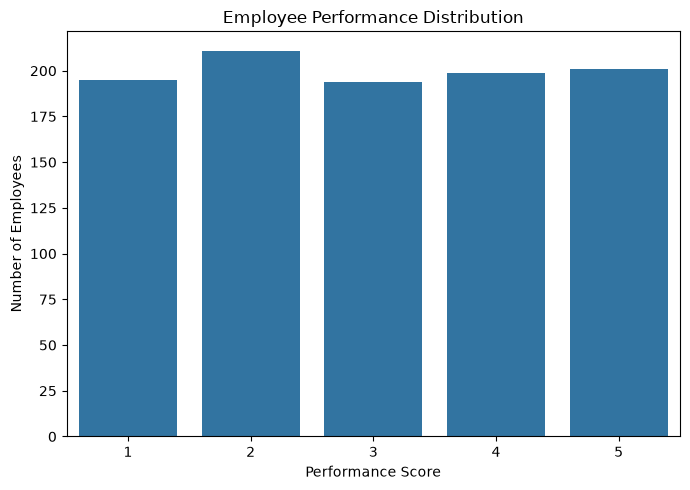

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Performance_Score")

plt.title("Employee Performance Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## Job Satisfaction Distribution

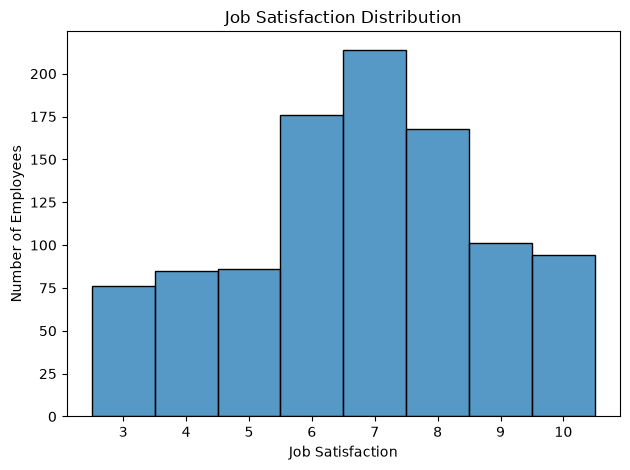

In [17]:
plt.Figure(figsize=(8, 5))

sns.histplot(data=df, x="Job_Satisfaction", bins=10, discrete=True)

plt.title("Job Satisfaction Distribution")

plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## Overtime and Job Satisfaction

In [18]:
overtime_satisfaction = df.groupby("Overtime")["Job_Satisfaction"].agg(
    ["mean", "median", "count"]
)
overtime_satisfaction

,mean,median,count
Overtime,,,
No,7.941176,8.0,510
Yes,5.500000,5.0,490


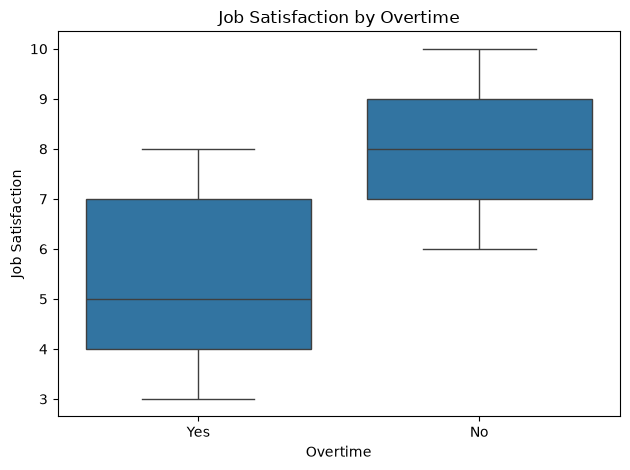

In [19]:
plt.Figure(figsize=(8, 5))
sns.boxplot(data=df, x="Overtime", y="Job_Satisfaction")

plt.title("Job Satisfaction by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Job Satisfaction")

plt.tight_layout()
plt.show()

## Employee Attrition Analysis

In [ ]:
attrition_counts = df["Attrition"].value_counts()
attrition_counts

Attrition
No     882
Yes    118
Name: count, dtype: int64

In [23]:
attrition_rate = df["Attrition"].eq("Yes").mean() * 100

print(f"Overall Attrition Rate: {attrition_rate}")

Overall Attrition Rate: 11.799999999999999


## Attrition Rate by Department

In [24]:
attrition_by_department = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)
attrition_by_department

Department
Marketing    14.795918
IT           12.637363
Sales        12.562814
HR           10.480349
Finance       8.762887
Name: Attrition, dtype: float64

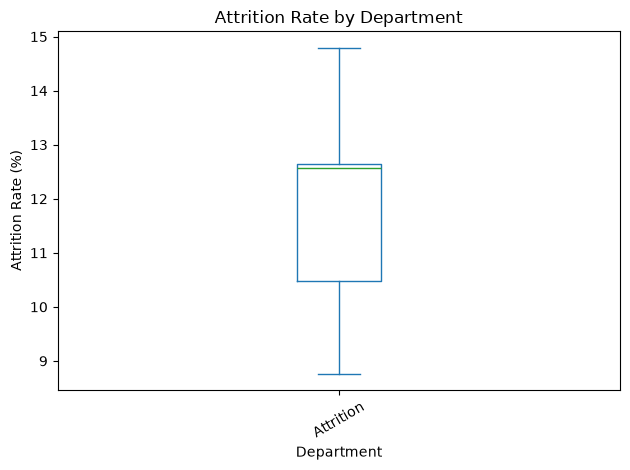

In [25]:
plt.Figure(figsize=(9, 5))

attrition_by_department.plot(kind="box")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Attrition and Job Satisfaction

In [26]:
attrition_satisfaction = df.groupby("Attrition")["Job_Satisfaction"].agg(
    ["mean", "median", "count"]
)

attrition_satisfaction

,mean,median,count
Attrition,,,
No,7.168934,7.0,882
Yes,3.576271,3.0,118


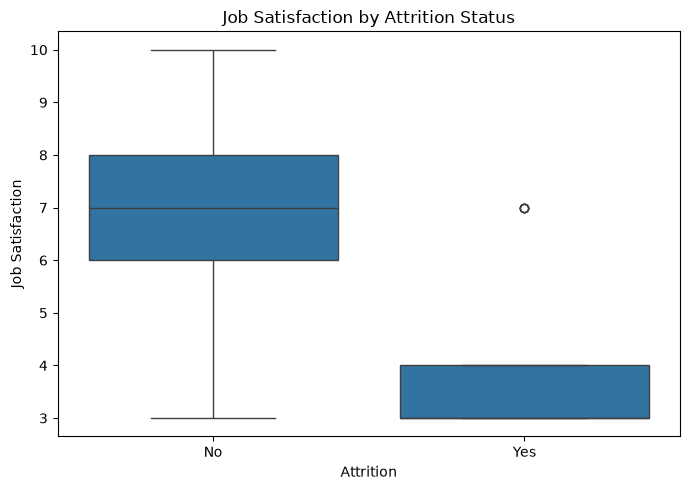

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="Attrition", y="Job_Satisfaction")

plt.title("Job Satisfaction by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Job Satisfaction")

plt.tight_layout()
plt.show()

## Attrition by Overtime Status

In [28]:
attrition_overtime = (
    pd.crosstab(df["Overtime"], df["Attrition"], normalize="index") * 100
)

attrition_overtime

Attrition,No,Yes
Overtime,,
No,100.000000,0.000000
Yes,75.918367,24.081633


## Correlation Analysis

In [29]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix.round(2)

,Employee_ID,Age,Experience,Salary,Performance_Score,Job_Satisfaction,Work_Hours,Training_Hours,Projects,Manager_Rating,Sick_Leaves
Employee_ID,1.00,-0.01,-0.01,-0.01,-0.02,-0.07,-0.02,0.02,-0.02,0.01,-0.01
Age,-0.01,1.00,0.63,0.56,0.05,0.00,0.03,-0.02,0.54,0.00,0.05
Experience,-0.01,0.63,1.00,0.82,0.02,-0.03,0.00,-0.03,0.78,0.02,0.04
Salary,-0.01,0.56,0.82,1.00,0.04,0.01,0.01,-0.05,0.86,0.02,0.03
Performance_Score,-0.02,0.05,0.02,0.04,1.00,-0.00,-0.02,-0.00,0.02,0.00,-0.02
Job_Satisfaction,-0.07,0.00,-0.03,0.01,-0.00,1.00,0.05,0.01,0.01,-0.00,-0.00
Work_Hours,-0.02,0.03,0.00,0.01,-0.02,0.05,1.00,0.01,0.01,-0.04,0.01
Training_Hours,0.02,-0.02,-0.03,-0.05,-0.00,0.01,0.01,1.00,-0.04,0.01,0.01
Projects,-0.02,0.54,0.78,0.86,0.02,0.01,0.01,-0.04,1.00,0.01,0.03
Manager_Rating,0.01,0.00,0.02,0.02,0.00,-0.00,-0.04,0.01,0.01,1.00,0.02


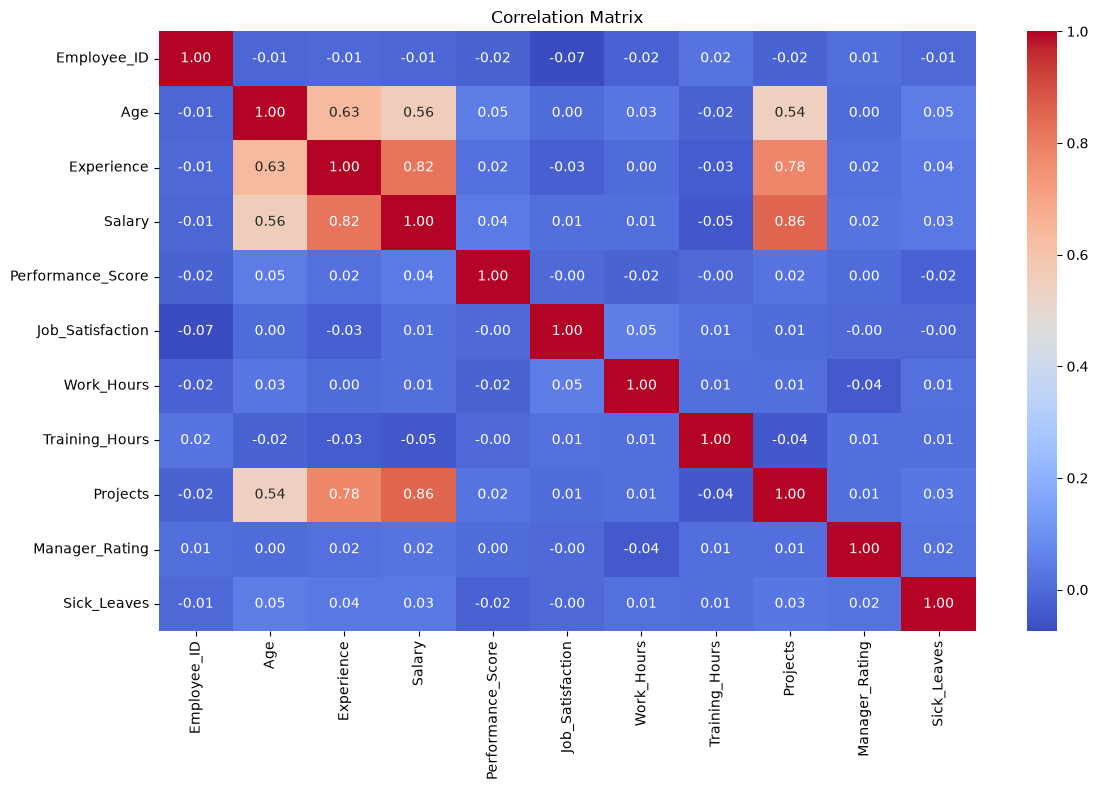

In [30]:
plt.figure(figsize=(12, 8))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## Business Questions

1. Which department has the highest average salary?
2. Which department has the highest attrition rate?
3. Does experience appear to influence salary?
4. Does overtime appear to be associated with job satisfaction?
5. Is lower job satisfaction associated with attrition?
6. Which employees have the highest performance scores?

In [31]:
print("1. Average Salary by Department")
print(df.groupby("Department")["Salary"].mean().sort_values(ascending=False))

print("\n2. Attrition Rate by Department")
print(attrition_by_department)

print("\n3. Average Salary by Experience")
print(df.groupby("Experience")["Salary"].mean().sort_index())

print("\n4. Average Job Satisfaction by Overtime")
print(df.groupby("Overtime")["Job_Satisfaction"].mean())

print("\n5. Average Job Satisfaction by Attrition")
print(df.groupby("Attrition")["Job_Satisfaction"].mean())

print("\n6. Average Performance by Department")
print(df.groupby("Department")["Performance_Score"].mean().sort_values(ascending=False))

1. Average Salary by Department
Department
Finance      133855.963273
Marketing    128487.834184
IT           128005.054258
HR           127708.982533
Sales        121986.391960
Name: Salary, dtype: float64

2. Attrition Rate by Department
Department
Marketing    14.795918
IT           12.637363
Sales        12.562814
HR           10.480349
Finance       8.762887
Name: Attrition, dtype: float64

3. Average Salary by Experience
Experience
0      55456.726744
1      56945.978261
2      55581.202532
3      85028.419355
4      86898.766129
5      83871.829787
6     123356.157407
7     126179.045455
8     134559.378676
9     126045.225806
10    121432.703704
11    192606.100000
12    200116.514286
13    195236.806452
14    189744.239130
15    203560.600000
16    191249.600000
17    203456.104167
18    192266.882353
19    196677.157895
20    199170.022727
21    194242.125000
22    185748.071429
23    203710.916667
24    204080.166667
25    173629.000000
26    202185.714286
27    189755.35714

## Save Clean EDA Dataset

In [32]:
df.to_csv("../data/processed/employee_hr_analytics_eda.csv", index=False)

print("EDA dataset saved successfully")

EDA dataset saved successfully
